# Day 5 - Visualization and Machine Learning Basics Full Examples

This notebook is the fully worked version of the Day 5 workbook.

It is designed to run both locally and in Google Colab:
- It uses built-in scikit-learn datasets rather than external files.
- It writes generated charts to a local `day5_outputs/` folder in the current working directory.
- The setup cell checks whether the core packages are available and installs them only if needed.

Main teaching goals:
- Review how to build visual explanations from clean tabular data.
- Show how grouped summaries connect naturally to charts.
- Introduce the supervised machine learning workflow in scikit-learn.
- Build one complete regression example and one complete classification example.
- Keep the code readable enough for teaching and live explanation.

Main example datasets:
- The iris dataset for visualization and classification.
- The diabetes dataset for a simple regression example.

Recommended usage:
1. Run the notebook from top to bottom.
2. Read the markdown before each code section.
3. Compare the plotted outputs with the analytical questions.
4. Use the final sections as a template for your own classroom live coding.


## Day 5 Map: From Summary Tables to Introductory Machine Learning

Day 5 is a bridge day rather than a hard jump into modeling.
- Day 4 focused on preparing, summarizing, and visualizing data.
- Day 5 keeps that discipline and only then introduces prediction.
- A model is useful only after the data and the question are clear.

Recommended teaching sequence:
- Start with a descriptive question.
- Build or inspect a summary table.
- Choose a chart that answers that question.
- Decide whether the next question is predictive.
- Define features `X` and target `y`.
- Split the data into train and test parts.
- Fit a simple model.
- Predict on unseen rows.
- Evaluate and interpret the result.

Questions worth repeating throughout the lesson:
- What does one row represent?
- Which column is the target?
- Would a grouped table already answer the question?
- What information is available at prediction time?
- Is a model actually necessary for this task?

Core message:
- Visualization is not separate from machine learning.
- Visualization helps check assumptions, spot outliers, notice class imbalance, and explain results.
- Good modeling starts with good descriptive analysis.


In [2]:
from __future__ import annotations

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

# These are the core libraries used in the notebook.
# Colab already includes them, but a local environment may not.
REQUIRED_PACKAGES = {
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
}

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

missing_packages = [
    package
    for module_name, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print('Installing missing packages:', ', '.join(missing_packages))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])

import numpy as np # NumPy ir skaitļošanas bazes biblioteka uz kura pamata strādā gan Pandas, gan principā visaa ar MI un AI saistītās bibliotekas
# pēc būtiba NumPY mums dod iespēju ar Python iegūt tādu pašu ātrumu kā dotu zema līmeņa valodas
# ka C, C++
# numpy tiek uzstādit automātiski uzstādot Pandas
print(f"Numpy version {np.__version__}")
import pandas as pd
print(f"Pandas version {pd.__version__}")

# Use a non-interactive backend only when the code is executed outside a notebook.
# This keeps inline charts working in Jupyter and Colab while still allowing headless verification.
if 'ipykernel' not in sys.modules:
    import matplotlib
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_diabetes, load_iris

try:
    import google.colab  # type: ignore  # noqa: F401
    RUNNING_IN_COLAB = True
except ModuleNotFoundError:
    RUNNING_IN_COLAB = False

SHOW_FIGURES = 'ipykernel' in sys.modules

WORKDIR = Path.cwd().resolve()
OUTPUT_DIR = WORKDIR / 'day5_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 3)

{
    'running_in_colab': RUNNING_IN_COLAB,
    'working_directory': str(WORKDIR),
    'output_directory': str(OUTPUT_DIR),
}


Numpy version 2.0.2
Pandas version 2.2.2


{'running_in_colab': True,
 'working_directory': '/content',
 'output_directory': '/content/day5_outputs'}

## Built-In Teaching Datasets

Why use built-in datasets for this lesson:
- They are small and quick to load.
- They do not require external downloads or file preparation.
- They keep the focus on concepts and workflow rather than file handling.
- They are widely used in tutorials, classrooms, and official documentation.

### Iris dataset
- A classic multi-class classification dataset.
- The official scikit-learn documentation describes it as a very easy dataset for classification.
- It has 150 rows, 4 numeric features, and 3 classes.
- It is useful for grouped summaries, distribution plots, scatter plots, and first classification examples.

### Diabetes dataset
- A classic small regression dataset.
- It is useful for contrasting a numeric target with a categorical target.
- It works well for a first `LinearRegression` example.
- It is also useful for showing that line charts require meaningful order rather than arbitrary categories.

Official references:
- [scikit-learn toy datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html)
- [load_iris](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)
- [Iris dataset example](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html)
- [load_diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)


In [3]:
# Load the iris and diabetes datasets as pandas-friendly tables.
iris = load_iris(as_frame=True)
diabetes = load_diabetes(as_frame=True)

iris_df = iris.frame.copy()
diabetes_df = diabetes.frame.copy()

# Add readable species labels for later summaries and charts.
target_name_lookup = dict(enumerate(iris.target_names))
iris_df['species'] = iris_df['target'].map(target_name_lookup)

dataset_overview = pd.DataFrame(
    [
        {
            'dataset': 'iris',
            'rows': iris_df.shape[0],
            'columns': iris_df.shape[1],
            'target_column': 'target',
            'task_type': 'classification',
        },
        {
            'dataset': 'diabetes',
            'rows': diabetes_df.shape[0],
            'columns': diabetes_df.shape[1],
            'target_column': 'target',
            'task_type': 'regression',
        },
    ]
)
# display ir tā ka print priekš tabulām, ja vajaga vienā šunā atrādīt vairākas
# atceramies ka tabulu no pēdejas šunas rindiņas mēs automatiski attēlojam kā display
display(dataset_overview)
display(iris_df.head())
display(diabetes_df.head())


,dataset,rows,columns,target_column,task_type
0,iris,150,6,target,classification
1,diabetes,442,11,target,regression


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038,0.051,0.062,0.022,-0.044,-0.035,-0.043,-0.003,0.020,-0.018,151.0
1,-0.002,-0.045,-0.051,-0.026,-0.008,-0.019,0.074,-0.039,-0.068,-0.092,75.0
2,0.085,0.051,0.044,-0.006,-0.046,-0.034,-0.032,-0.003,0.003,-0.026,141.0
3,-0.089,-0.045,-0.012,-0.037,0.012,0.025,-0.036,0.034,0.023,-0.009,206.0
4,0.005,-0.045,-0.036,0.022,0.004,0.016,0.008,-0.003,-0.032,-0.047,135.0


In [5]:
# nedaudz par iris
# sīkāk var atrast šeit: https://archive.ics.uci.edu/dataset/53/iris
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
# now let's see what we have about diabetes
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

## Anscombe's Quartet: Same Summary Statistics, Very Different Pictures

Before building almost any other chart in this notebook, it is worth revisiting one of the classic warnings in data analysis: **summary statistics do not tell the whole story**.

Anscombe's quartet is a famous set of four small datasets introduced by statistician Francis Anscombe in 1973.
- The four datasets have nearly identical simple descriptive statistics.
- They have nearly the same means, variances, correlation, and linear regression line.
- But when plotted, they look dramatically different.

Why this matters:
- A table of metrics can hide nonlinear structure.
- A single outlier can distort correlation and regression.
- A high-leverage point can create the illusion of a strong relationship.
- Visualization should happen early, not only at the end of analysis.

What the four panels typically show:
- Dataset I: a fairly ordinary linear-looking relationship.
- Dataset II: a clearly curved relationship that a straight line does not describe well.
- Dataset III: a mostly linear pattern with one influential outlier.
- Dataset IV: one high-leverage point creates a misleading regression relationship.

This is exactly the lesson that supports the rest of Day 5:
- Do not trust metrics blindly.
- Plot the data before believing the model summary.
- Use visualization to validate assumptions before moving into machine learning.

References:
- [Anscombe's quartet (Wikipedia)](https://en.wikipedia.org/wiki/Anscombe%27s_quartet)
- [Anscombe (1973), Graphs in Statistical Analysis, DOI](https://doi.org/10.1080/00031305.1973.10478966)


,x_mean,y_mean,x_variance,y_variance,correlation,slope,intercept,r_squared
dataset,,,,,,,,
I,9.0,7.501,11.0,4.127,0.816,0.5,3.000,0.667
II,9.0,7.501,11.0,4.128,0.816,0.5,3.001,0.666
III,9.0,7.500,11.0,4.123,0.816,0.5,3.002,0.666
IV,9.0,7.501,11.0,4.123,0.817,0.5,3.002,0.667


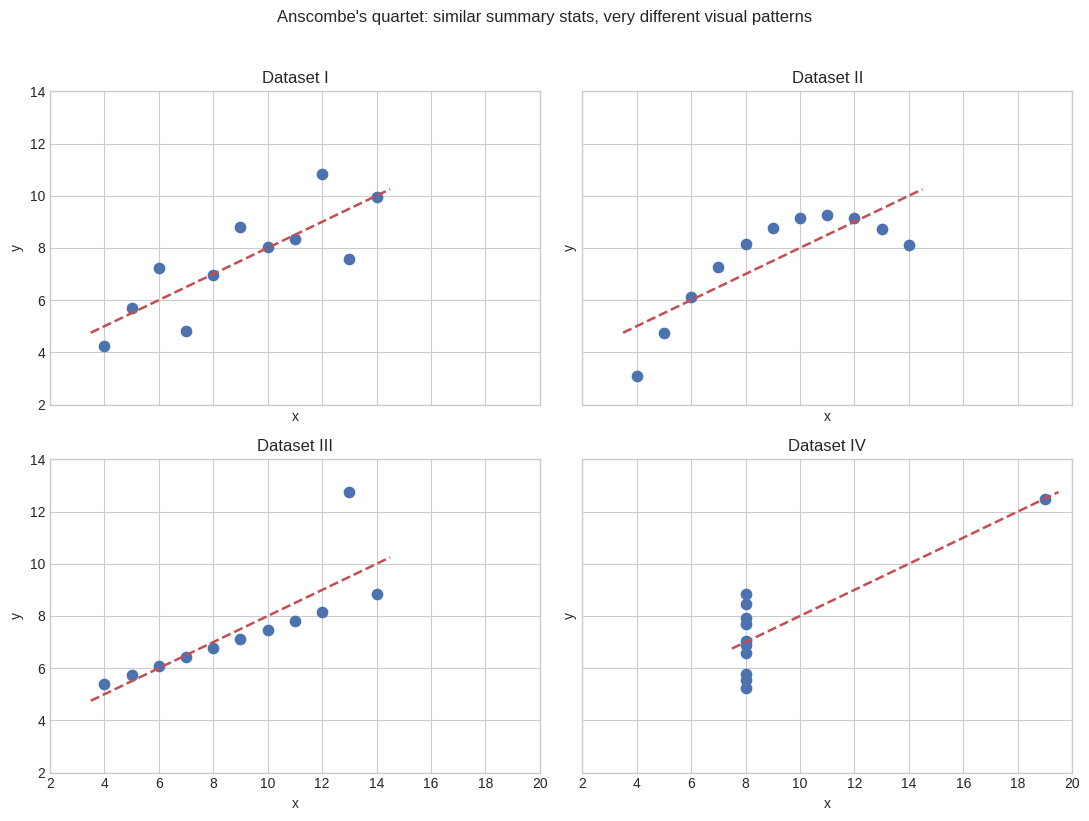

'anscombe_quartet.png'

In [7]:
# Anscombe's quartet is included here near the start of the notebook
# because it is one of the clearest demonstrations that summary metrics
# are not enough to understand a dataset.

# The values below are the canonical four datasets.
anscombe_data = {
    'I': {
        'x': [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0],
        'y': [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    },
    'II': {
        'x': [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0],
        'y': [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    },
    'III': {
        'x': [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0],
        'y': [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    },
    'IV': {
        'x': [8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 19.0, 8.0, 8.0, 8.0],
        'y': [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
    },
}

anscombe_records = []
for dataset_name, values in anscombe_data.items():
    for x_value, y_value in zip(values['x'], values['y']):
        anscombe_records.append(
            {
                'dataset': dataset_name,
                'x': x_value,
                'y': y_value,
            }
        )

anscombe_df = pd.DataFrame(anscombe_records)

summary_rows = []
for dataset_name, group in anscombe_df.groupby('dataset', observed=False):
    x_values = group['x'].to_numpy()
    y_values = group['y'].to_numpy()

    # Use sample variance (ddof=1) to match the standard descriptive-statistics convention.
    slope, intercept = np.polyfit(x_values, y_values, deg=1)
    predicted = intercept + slope * x_values
    ss_res = ((y_values - predicted) ** 2).sum()
    ss_tot = ((y_values - y_values.mean()) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    summary_rows.append(
        {
            'dataset': dataset_name,
            'x_mean': x_values.mean(),
            'y_mean': y_values.mean(),
            'x_variance': x_values.var(ddof=1),
            'y_variance': y_values.var(ddof=1),
            'correlation': np.corrcoef(x_values, y_values)[0, 1],
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_squared,
        }
    )

anscombe_summary = pd.DataFrame(summary_rows).set_index('dataset').round(3)
display(anscombe_summary)

# Plot the four datasets side by side so the visual differences are obvious.
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, dataset_name in zip(axes, ['I', 'II', 'III', 'IV']):
    group = anscombe_df.loc[anscombe_df['dataset'] == dataset_name]
    x_values = group['x'].to_numpy()
    y_values = group['y'].to_numpy()

    # Fit the same type of simple linear regression line to each dataset.
    slope, intercept = np.polyfit(x_values, y_values, deg=1)
    x_line = np.linspace(x_values.min() - 0.5, x_values.max() + 0.5, 100)
    y_line = intercept + slope * x_line

    ax.scatter(x_values, y_values, color='#4c72b0', s=55)
    ax.plot(x_line, y_line, color='#c44e52', linestyle='--', linewidth=1.8)
    ax.set_title(f'Dataset {dataset_name}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)

fig.suptitle('Anscombe\'s quartet: similar summary stats, very different visual patterns', y=1.02)
fig.tight_layout()

anscombe_chart_path = OUTPUT_DIR / 'anscombe_quartet.png'
fig.savefig(anscombe_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

anscombe_chart_path.name


In [ ]:
# bonus papētīt ar jaunāko Datazaurus dozen ttps://en.wikipedia.org/wiki/Datasaurus_dozen

In [9]:
# nedaudz par datu pārveidošanu augšējai vizualizācijai
# pirmās un pēdejās 3 rindiņas
anscombe_records[:3], anscombe_records[-3:]

([{'dataset': 'I', 'x': 10.0, 'y': 8.04},
  {'dataset': 'I', 'x': 8.0, 'y': 6.95},
  {'dataset': 'I', 'x': 13.0, 'y': 7.58}],
 [{'dataset': 'IV', 'x': 8.0, 'y': 5.56},
  {'dataset': 'IV', 'x': 8.0, 'y': 7.91},
  {'dataset': 'IV', 'x': 8.0, 'y': 6.89}])

In [11]:
# iebarojot šādu sarakstu ar vārdnīcām Dataframe mēs iegustam plakanu tabulu
df = pd.DataFrame(anscombe_records)
display(df.head(3))
display(df.tail(3))

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58


,dataset,x,y
41,IV,8.0,5.56
42,IV,8.0,7.91
43,IV,8.0,6.89


In [12]:
# let's extract first dataset
anscombe_1 = df[df['dataset'] == 'I']
display(anscombe_1.head(3))
display(anscombe_1.tail(3))
# varētu jau mest nost dataset kolonu jo šeit jau ir tikai no pirmās dataset

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58


,dataset,x,y
8,I,12.0,10.84
9,I,7.0,4.82
10,I,5.0,5.68


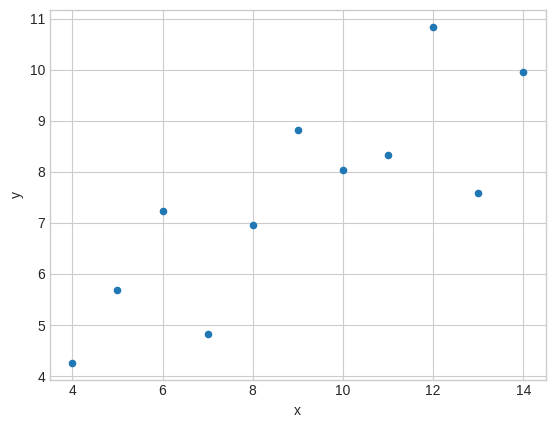

In [16]:
axes_object = anscombe_1.plot.scatter(x='x', y='y')
axes_object.get_figure().savefig('anscombe_1.png')

## Start with a Summary Table Before Drawing a Chart

A common beginner mistake is to plot raw data immediately without first deciding what question the chart should answer.

Better sequence:
- Clarify the question.
- Decide whether the answer should come from raw rows or from a grouped summary.
- Build the summary table first when comparison between groups is the main goal.
- Then choose a chart that communicates that summary clearly.

Example descriptive questions for iris:
- How many rows belong to each species?
- Which species has the largest average petal length?
- How different are the feature distributions across species?

This section keeps the Day 4 discipline visible before we move into modeling.


In [21]:
iris_df.sample(10, random_state = 2026)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
90,5.5,2.6,4.4,1.2,1,versicolor
127,6.1,3.0,4.9,1.8,2,virginica
101,5.8,2.7,5.1,1.9,2,virginica
42,4.4,3.2,1.3,0.2,0,setosa
18,5.7,3.8,1.7,0.3,0,setosa
149,5.9,3.0,5.1,1.8,2,virginica
15,5.7,4.4,1.5,0.4,0,setosa
23,5.1,3.3,1.7,0.5,0,setosa
65,6.7,3.1,4.4,1.4,1,versicolor
50,7.0,3.2,4.7,1.4,1,versicolor


In [17]:
iris_df.describe()
# tātad ja count ir zem iris_df.shape[0] tas nozīme ka tajā kolonā ir kāda neskaitliska vērtīb Nan

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000


In [22]:
# Create grouped summaries that will later feed the charts.
species_counts = iris_df['species'].value_counts().sort_index()

species_feature_summary = (
    iris_df.groupby('species', observed=False)[iris.feature_names]
    .agg(['mean', 'median'])
    .round(2)
)

mean_petal_by_species = (
    iris_df.groupby('species', observed=False)['petal length (cm)']
    .mean()
    .round(2)
    .sort_values()
)

display(species_counts.rename('row_count').to_frame())
display(mean_petal_by_species.rename('average_petal_length_cm').to_frame())
display(species_feature_summary)


,row_count
species,
setosa,50
versicolor,50
virginica,50


,average_petal_length_cm
species,
setosa,1.46
versicolor,4.26
virginica,5.55


sepal length (cm)        sepal width (cm)        petal length (cm)        petal width (cm)       
                        mean median             mean median              mean median             mean median
species                                                                                                     
setosa                  5.01    5.0             3.43    3.4              1.46   1.50             0.25    0.2
versicolor              5.94    5.9             2.77    2.8              4.26   4.35             1.33    1.3
virginica               6.59    6.5             2.97    3.0              5.55   5.55             2.03    2.0

In [24]:
# jebkurai tabula var lietot len vai shape
print("Rindu skaits iris_df", len(iris_df)) # len ir visparīga Python funkcija jebkādai skaitāmai strukturai, stringiem(simboli), sarakstiem (elementi), vardnīcam(key-valu pāri), DataFrame (rindiņu skaits)
print("Rindu skaits iris_df", iris_df.shape[0])


Rindu skaits iris_df 150
Rindu skaits iris_df 150


## Visualization Mindset Before Modeling

A chart is not decoration.
- A chart is a compact answer to a question.
- A chart should make comparison, change, spread, or relationship easier to see.
- A chart should reduce confusion rather than add it.

Questions to ask before plotting:
- Am I showing change over time, category comparison, distribution, or relationship?
- Do I need raw row-level data or a grouped summary table first?
- What should the audience learn in 10 seconds?
- Which labels, units, and titles are required to make the plot self-explanatory?

Practical chart habits:
- Use the simplest chart that matches the question.
- Label axes clearly.
- Put meaningful titles on charts.
- Keep colors consistent across related charts.
- Avoid clutter, chart junk, and accidental 3D effects.
- Sort categories when ranking is part of the message.
- Be careful with scales so comparisons remain honest.

Why this matters for machine learning:
- Visualization often reveals outliers, skew, overlap between classes, or missing structure.
- Visualization can show whether the target is imbalanced or noisy.
- Visualization helps explain model behavior to non-technical audiences.
- Good modeling often starts with good plotting.

Official references:
- [Matplotlib quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html)
- [Matplotlib plot types overview](https://matplotlib.org/stable/plot_types/)
- [pandas.DataFrame.plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html)


## Core Chart Families Used in This Notebook

### Bar charts
- Best for comparing categories or grouped summaries.
- Good when the audience needs precise magnitude comparison.
- In this notebook, bar charts answer species-count and average-petal-length questions.

### Histograms
- Best for the distribution of one numeric variable.
- Useful for center, spread, skew, and possible outliers.
- In this notebook, a histogram shows the spread of iris sepal length.

### Box plots
- Best for compact comparison of distributions across groups.
- Useful for medians, spread, and possible outliers.
- In this notebook, a box plot compares petal-length distributions by species.

### Scatter plots
- Best for relationships between two numeric variables.
- Useful for pattern, clusters, and possible class overlap.
- In this notebook, a scatter plot helps show why iris is a good introductory classification example.

### Heatmap-like matrix plots
- Useful when a matrix of values should be scanned quickly.
- In this notebook, a feature-correlation matrix is displayed with `imshow()`.

### Line charts
- Best when the x-axis has meaningful order.
- Weak choice for unordered categories.
- In this notebook, a line chart is used for an ordered sequence of BMI quintiles in the diabetes dataset.

Useful rule of thumb:
- Ordered sequence -> line chart.
- Category comparison -> bar chart.
- One-variable spread -> histogram or box plot.
- Numeric relationship -> scatter plot.
- Dense matrix of values -> heatmap-like display.


In [26]:
species_counts.head()

,count
species,
setosa,50
versicolor,50
virginica,50


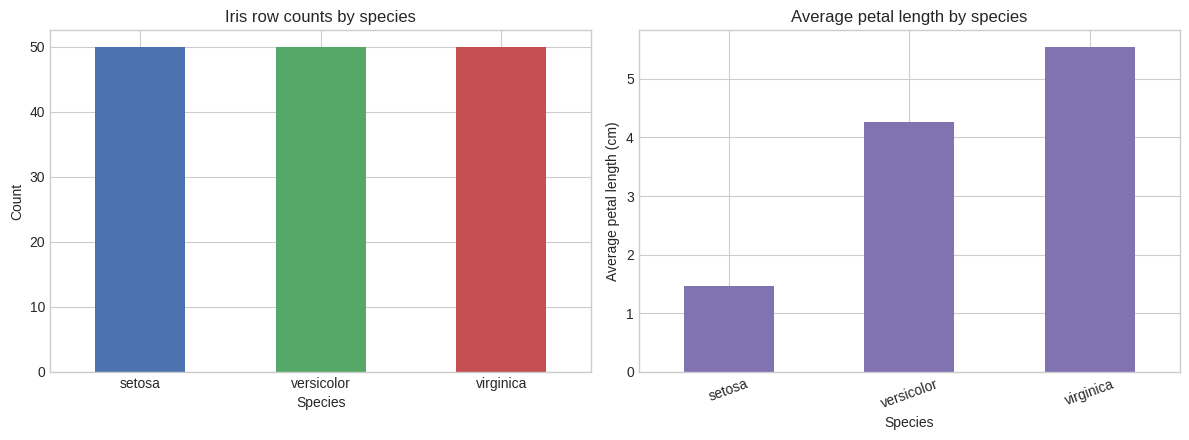

'iris_bar_charts.png'

In [25]:
# Build two simple bar charts from grouped summaries.
# The first answers a count question and the second answers a mean-comparison question.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

species_counts.plot(
    kind='bar',
    ax=axes[0], # tas norāda kura vizualizacija tā būs šūna, ja ir viena tad nevajag
    color=['#4c72b0', '#55a868', '#c44e52'],
)
# te var redzēt kā pielikt klāt šos papildu paskaidrojumus
axes[0].set_title('Iris row counts by species')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

mean_petal_by_species.plot(
    kind='bar',
    ax=axes[1],
    color='#8172b2',
)
axes[1].set_title('Average petal length by species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Average petal length (cm)')
axes[1].tick_params(axis='x', rotation=20)

fig.tight_layout()

bar_chart_path = OUTPUT_DIR / 'iris_bar_charts.png'
fig.savefig(bar_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

bar_chart_path.name


<Axes: title={'center': 'Iris row counts by species'}, xlabel='Species', ylabel='Count'>

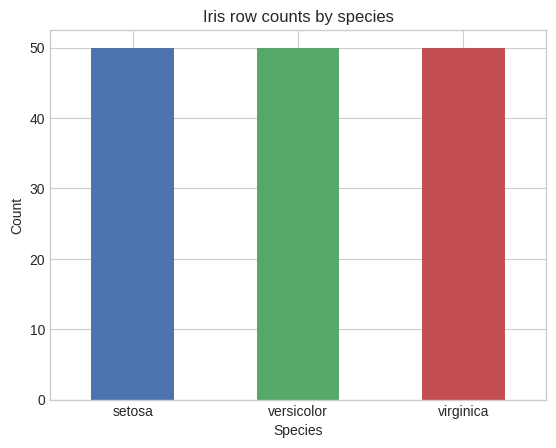

In [33]:
# if i want only species_count in one plot
species_counts.plot(
    kind='bar',
    color=['#4c72b0', '#55a868', '#c44e52'],
    title='Iris row counts by species',
    xlabel='Species',
    ylabel='Count',
    # roate x axis labels to 0
    rot=0,
)

/tmp/ipykernel_10923/3083454938.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(petal_length_groups, labels=iris.target_names)


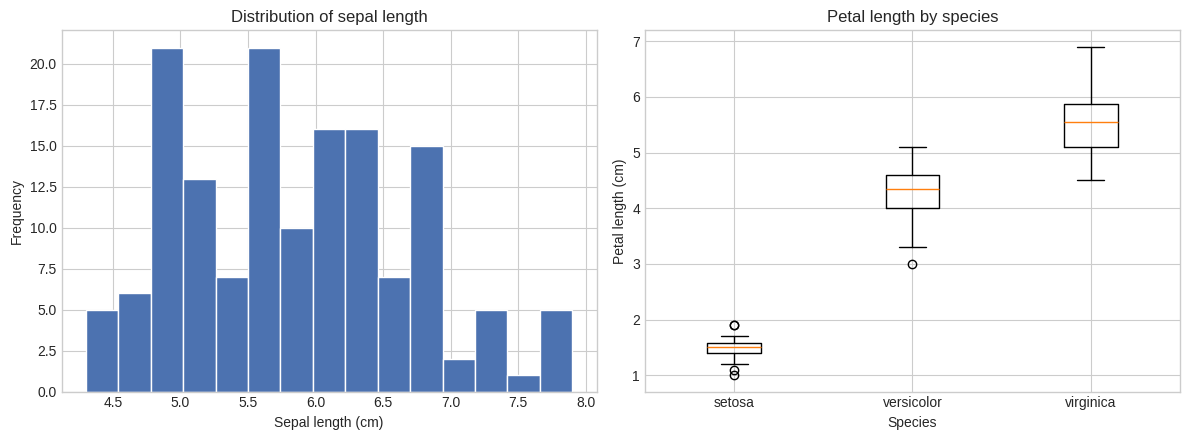

'iris_distribution_charts.png'

In [34]:
# Show two different distribution views.
# Histogram: one numeric variable overall.
# Box plot: one numeric variable compared across groups.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

iris_df['sepal length (cm)'].plot(
    kind='hist',
    bins=15,
    edgecolor='white',
    color='#4c72b0',
    ax=axes[0],
)
axes[0].set_title('Distribution of sepal length')
axes[0].set_xlabel('Sepal length (cm)')
axes[0].set_ylabel('Frequency')

petal_length_groups = [
    iris_df.loc[iris_df['species'] == species, 'petal length (cm)']
    for species in iris.target_names
]
axes[1].boxplot(petal_length_groups, labels=iris.target_names)
axes[1].set_title('Petal length by species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Petal length (cm)')

fig.tight_layout()

distribution_chart_path = OUTPUT_DIR / 'iris_distribution_charts.png'
fig.savefig(distribution_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

distribution_chart_path.name


<Axes: xlabel='sepal length (cm)', ylabel='Count'>

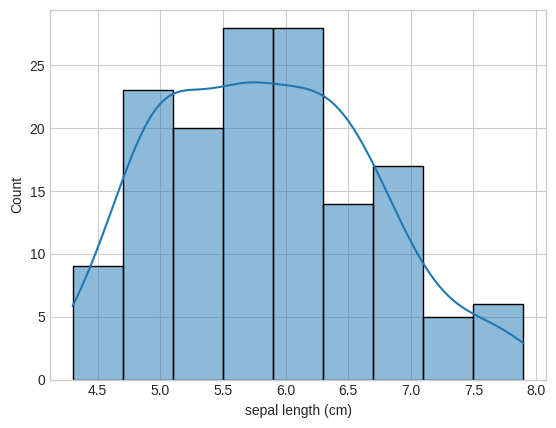

In [37]:
# let's import seaborn which is a helper library for matplotlib
import seaborn as sns # šī arī būtu jauzstāda atsevišķi
# let's plot histogram for 'sepal length (cm)' column
# sns.histplot(iris_df['sepal length (cm)'], bins=25, color='#4c72b0')
# izmantojot kde - Kernel Density mēs iegustām neatkarīgu no bin skaita attēlojumu
sns.histplot(iris_df['sepal length (cm)'], kde=True)

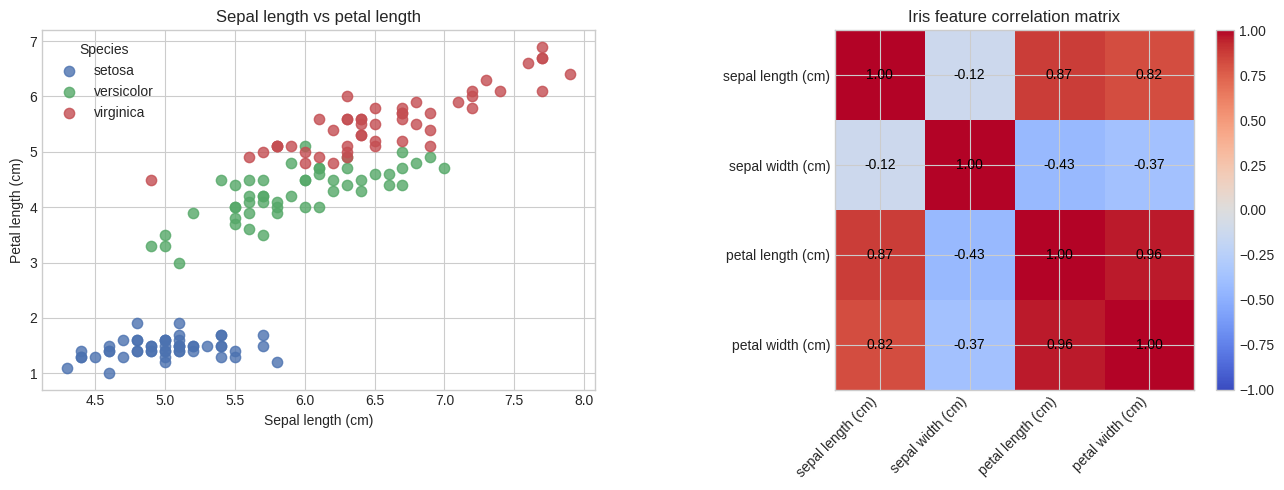

'iris_relationship_and_correlation.png'

In [38]:
# Show a feature relationship and a compact matrix-style summary.
# The scatter plot helps explain class separation.
# The correlation matrix helps summarize pairwise relationships between features.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette = {
    'setosa': '#4c72b0',
    'versicolor': '#55a868',
    'virginica': '#c44e52',
}

for species, group in iris_df.groupby('species', observed=False):
    axes[0].scatter(
        group['sepal length (cm)'],
        group['petal length (cm)'],
        label=species,
        color=palette[species],
        alpha=0.8,
        s=55,
    )

axes[0].set_title('Sepal length vs petal length')
axes[0].set_xlabel('Sepal length (cm)')
axes[0].set_ylabel('Petal length (cm)')
axes[0].legend(title='Species')

correlation = iris_df[iris.feature_names].corr().round(2)
heatmap = axes[1].imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Iris feature correlation matrix')
axes[1].set_xticks(range(len(correlation.columns)))
axes[1].set_xticklabels(correlation.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(correlation.index)))
axes[1].set_yticklabels(correlation.index)

for row_index in range(correlation.shape[0]):
    for col_index in range(correlation.shape[1]):
        axes[1].text(
            col_index,
            row_index,
            f"{correlation.iloc[row_index, col_index]:.2f}",
            ha='center',
            va='center',
            color='black',
        )

fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()

relationship_chart_path = OUTPUT_DIR / 'iris_relationship_and_correlation.png'
fig.savefig(relationship_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

relationship_chart_path.name


In [ ]:
# A line chart needs meaningful order on the x-axis.
# The raw diabetes rows are not time data, so we create an ordered set of BMI quintiles.

diabetes_viz_df = diabetes_df.copy()
diabetes_viz_df['bmi_quintile'] = pd.qcut(
    diabetes_viz_df['bmi'],
    q=5,
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'],
)

bmi_trend = (
    diabetes_viz_df.groupby('bmi_quintile', observed=False)['target']
    .mean()
    .round(1)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
bmi_trend.plot(ax=ax, marker='o', linewidth=2, color='#dd8452')
ax.set_title('Average diabetes target by BMI quintile')
ax.set_xlabel('BMI quintile')
ax.set_ylabel('Average target value')
ax.set_ylim(bottom=0)

for x_position, y_value in enumerate(bmi_trend.values):
    ax.text(x_position, y_value + 2, f'{y_value:.1f}', ha='center')

fig.tight_layout()

line_chart_path = OUTPUT_DIR / 'diabetes_bmi_quintile_line_chart.png'
fig.savefig(line_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

display(bmi_trend.rename('average_target').to_frame())
line_chart_path.name


## Machine Learning Workflow Overview

At this stage, machine learning should feel like an extension of the Day 4 workflow rather than a separate universe.

Key ideas:
- Machine learning is about learning patterns from examples.
- In supervised learning, we already know the correct target for historical rows.
- We use those historical rows to train a model.
- We then ask the model to predict the target for unseen rows.

Important vocabulary:
- `X`: the feature matrix, meaning the input columns used for prediction.
- `y`: the target, meaning the column we want to predict.
- Train set: the rows used to fit the model.
- Test set: the rows held back for evaluation.
- Estimator: the scikit-learn term for an object that learns from data.
- Prediction: the model output for new or held-out rows.
- Metric: a numerical summary of prediction quality.

A practical starter workflow:
- Clarify the problem.
- Decide whether it is regression or classification.
- Choose candidate input columns.
- Remove columns that leak the answer.
- Split the data into train and test subsets.
- Fit a simple baseline model.
- Predict on the test set.
- Evaluate with a metric that matches the task.
- Interpret the result in business or statistical terms.

Common pitfalls:
- Treating machine learning as a substitute for data cleaning.
- Forgetting to separate training and test data.
- Evaluating only on the training data.
- Using a metric that does not match the real decision problem.
- Ignoring class imbalance or outliers.
- Using columns that would not be available at prediction time.

Official references:
- [scikit-learn Getting Started](https://scikit-learn.org/stable/getting_started.html)
- [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [Model selection and evaluation](https://scikit-learn.org/stable/model_selection)


## How scikit-learn Organizes the Work

One reason scikit-learn is useful for teaching is that many tools share the same mental model.

Estimator pattern:
- Create an estimator object.
- Call `.fit(X, y)` on training data.
- Call `.predict(X_new)` on new data.
- Use metrics to evaluate predictions.

Main scikit-learn building blocks to remember:
- `sklearn.datasets`: sample datasets such as iris and diabetes.
- `sklearn.model_selection`: splitting data and validation tools.
- `sklearn.preprocessing`: scaling, encoding, and transformation tools.
- `sklearn.linear_model`: simple baseline models such as `LinearRegression` and `LogisticRegression`.
- `sklearn.metrics`: task-specific evaluation functions.
- `sklearn.pipeline`: combine preprocessing and modeling into one repeatable workflow.

Why this matters pedagogically:
- Students can learn one core API and reuse it across many estimators.
- It becomes easier to compare models because the workflow stays similar.
- It encourages reproducible, stepwise work instead of manual trial-and-error.

Good beginner habits:
- Use `as_frame=True` when you want a pandas-friendly example.
- Keep feature selection explicit.
- Set `random_state` in demos when reproducibility matters.
- Start with a simple baseline before discussing more complex models.
- Interpret the metric before trying to improve the model.

Official references:
- [scikit-learn Getting Started](https://scikit-learn.org/stable/getting_started.html)
- [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [make_pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)
- [Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)


In [ ]:
from sklearn.model_selection import train_test_split

# Classification task setup with iris.
X_cls = iris_df[iris.feature_names].copy()
y_cls = iris_df['target'].copy()

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls,
)

# Regression task setup with diabetes.
X_reg = diabetes_df.drop(columns=['target']).copy()
y_reg = diabetes_df['target'].copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42,
)

split_overview = pd.DataFrame(
    [
        {
            'task': 'classification',
            'dataset': 'iris',
            'train_rows': len(X_cls_train),
            'test_rows': len(X_cls_test),
            'feature_count': X_cls_train.shape[1],
            'target_type': 'categorical',
        },
        {
            'task': 'regression',
            'dataset': 'diabetes',
            'train_rows': len(X_reg_train),
            'test_rows': len(X_reg_test),
            'feature_count': X_reg_train.shape[1],
            'target_type': 'numeric',
        },
    ]
)

display(split_overview)
display(X_cls_train.head())
display(X_reg_train.head())


## Regression Basics

Use regression when the target is numeric.
- Example questions: predicting sales, revenue, cost, demand, temperature, or a score.
- The output is a number rather than a class label.

Worked example in this notebook:
- Use the diabetes dataset as a small regression example.
- Start with `LinearRegression` as a baseline model.
- Keep the first example simple so the class can focus on workflow and metrics.

What `LinearRegression` represents:
- A baseline linear model.
- A model that estimates coefficients for features in order to minimize residual error.
- A useful starting point for discussion even when the real relationship is more complex.

Core regression metrics used here:
- `MAE`: average absolute prediction error, easy to explain in the original target units.
- `RMSE`: similar to MAE but penalizes larger errors more strongly.
- `R^2`: compares the model to a baseline that predicts the mean target value.

Interpretation reminders:
- Lower `MAE` is better.
- Lower `RMSE` is better.
- Higher `R^2` is better, but it can be negative if the model is worse than a naive baseline.
- Metrics should be interpreted together with the real scale of the problem.

Official references:
- [load_diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)
- [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [mean_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)
- [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
- [r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fit a simple regression model.
# This is deliberately a baseline example: clear, short, and easy to explain.
regression_model = LinearRegression()
regression_model.fit(X_reg_train, y_reg_train)

# Predict on the held-out test set so the evaluation is honest.
y_reg_pred = regression_model.predict(X_reg_test)

# Compute common regression metrics.
regression_metrics = pd.Series(
    {
        'MAE': mean_absolute_error(y_reg_test, y_reg_pred),
        'RMSE': mean_squared_error(y_reg_test, y_reg_pred) ** 0.5,
        'R2': r2_score(y_reg_test, y_reg_pred),
    }
).round(3)

# Pair each feature with its fitted coefficient.
regression_coefficients = pd.DataFrame(
    {
        'feature': X_reg_train.columns,
        'coefficient': regression_model.coef_,
    }
)
regression_coefficients['abs_coefficient'] = regression_coefficients['coefficient'].abs()
regression_coefficients = regression_coefficients.sort_values('abs_coefficient', ascending=False)

# Build a compact prediction review table.
regression_results = pd.DataFrame(
    {
        'actual_target': y_reg_test.reset_index(drop=True),
        'predicted_target': pd.Series(y_reg_pred).round(2),
    }
)
regression_results['residual'] = (
    regression_results['actual_target'] - regression_results['predicted_target']
).round(2)

display(regression_metrics.rename('value').to_frame())
display(regression_coefficients[['feature', 'coefficient']].head(10).round(4))
display(regression_results.head(10))


In [ ]:
# Plot actual vs predicted values and the residual distribution.
# These charts make regression quality easier to explain than metrics alone.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(
    regression_results['actual_target'],
    regression_results['predicted_target'],
    color='#4c72b0',
    alpha=0.8,
)
min_value = min(regression_results['actual_target'].min(), regression_results['predicted_target'].min())
max_value = max(regression_results['actual_target'].max(), regression_results['predicted_target'].max())
axes[0].plot([min_value, max_value], [min_value, max_value], linestyle='--', color='black')
axes[0].set_title('Actual vs predicted diabetes target')
axes[0].set_xlabel('Actual target')
axes[0].set_ylabel('Predicted target')

axes[1].hist(
    regression_results['residual'],
    bins=12,
    edgecolor='white',
    color='#55a868',
)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual = actual - predicted')
axes[1].set_ylabel('Frequency')

fig.tight_layout()

regression_chart_path = OUTPUT_DIR / 'diabetes_regression_diagnostics.png'
fig.savefig(regression_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

regression_chart_path.name


## Classification Basics

Use classification when the target is categorical.
- Example questions: which species, fraud or not fraud, churn or not churn, pass or fail.
- The output is a class label or class probability.

Worked example in this notebook:
- Use iris species as the target.
- Start with `LogisticRegression` as a simple, standard baseline classifier.
- Wrap it in a pipeline with `StandardScaler` to demonstrate a common scikit-learn workflow pattern.

What to explain about classification:
- The model learns boundaries between classes from historical examples.
- Some problems are binary and some are multi-class.
- Iris is a multi-class example, which makes it good for classroom discussion.

Core classification metrics used here:
- `accuracy`: fraction of correctly predicted rows.
- `precision`: when the model predicts a class, how often is it right?
- `recall`: how many of the true instances of a class did the model find?

Interpretation reminders:
- Accuracy is easy to understand but not always enough.
- Precision and recall matter more when the cost of false positives and false negatives differs.
- In multi-class problems, averages such as `macro` averaging should be explained explicitly.

Official references:
- [load_iris](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)
- [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [make_pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)
- [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
- [precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
- [recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Build a simple pipeline.
# The scaler standardizes the numeric features and the classifier predicts the class.
classification_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=300, random_state=42),
)

classification_model.fit(X_cls_train, y_cls_train)
y_cls_pred = classification_model.predict(X_cls_test)

classification_metrics = pd.Series(
    {
        'accuracy': accuracy_score(y_cls_test, y_cls_pred),
        'precision_macro': precision_score(y_cls_test, y_cls_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_cls_test, y_cls_pred, average='macro', zero_division=0),
    }
).round(3)

classification_report_df = pd.DataFrame(
    classification_report(
        y_cls_test,
        y_cls_pred,
        target_names=iris.target_names,
        output_dict=True,
        zero_division=0,
    )
).T.round(3)

classification_preview = X_cls_test.reset_index(drop=True).copy()
classification_preview['actual_target'] = y_cls_test.reset_index(drop=True)
classification_preview['predicted_target'] = y_cls_pred
classification_preview['actual_species'] = classification_preview['actual_target'].map(target_name_lookup)
classification_preview['predicted_species'] = classification_preview['predicted_target'].map(target_name_lookup)

display(classification_metrics.rename('value').to_frame())
display(classification_report_df)
display(classification_preview.head(10))


In [ ]:
from sklearn.metrics import confusion_matrix

# Build a confusion matrix to show which classes were predicted correctly or confused.
cm = confusion_matrix(y_cls_test, y_cls_pred)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f'actual_{name}' for name in iris.target_names],
    columns=[f'predicted_{name}' for name in iris.target_names],
)

display(confusion_matrix_df)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion matrix for iris classification')
ax.set_xlabel('Predicted class')
ax.set_ylabel('Actual class')
ax.set_xticks(range(len(iris.target_names)))
ax.set_xticklabels(iris.target_names, rotation=30, ha='right')
ax.set_yticks(range(len(iris.target_names)))
ax.set_yticklabels(iris.target_names)

for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        ax.text(
            col_index,
            row_index,
            str(cm[row_index, col_index]),
            ha='center',
            va='center',
            color='black',
        )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

classification_chart_path = OUTPUT_DIR / 'iris_confusion_matrix.png'
fig.savefig(classification_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

classification_chart_path.name


## Unsupervised Learning: Clustering for Structure Discovery

So far, the notebook has used **supervised learning**, where we already know the target column.

Clustering is different:
- Clustering is an **unsupervised** learning task.
- We do not provide a target label such as species.
- The algorithm groups rows based on feature similarity.
- The goal is often exploration rather than direct prediction.

Why this belongs in an analysis workflow:
- Clustering can reveal natural structure in the data.
- It can help show whether groups appear well separated or heavily mixed.
- It can support segmentation-style questions.
- It can help surface unusual rows that sit far from cluster centers.

Important caution:
- `KMeans` is mainly a **clustering** algorithm, not a dedicated outlier detector.
- It can still provide a useful first heuristic for unusual observations through distance to centroid.
- For more explicit anomaly detection, use tools designed for that purpose, such as `IsolationForest`.

Official references:
- [scikit-learn clustering user guide](https://scikit-learn.org/stable/modules/clustering.html)
- [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [Outlier and novelty detection](https://scikit-learn.org/stable/modules/outlier_detection.html)


## KMeans on Iris

Why iris works well here:
- It has a small number of numeric features.
- It contains three known species, which makes post-hoc comparison easy.
- The clusters are not perfectly separated, which is useful for discussion.

Why feature scaling matters before KMeans:
- KMeans uses Euclidean distance.
- A feature with a larger scale can dominate the distance calculation.
- Standardizing features helps keep each variable on a comparable footing.

What to inspect after fitting KMeans:
- Cluster sizes.
- Cluster centers.
- Cross-tabulation of clusters against known labels.
- Whether the discovered groups roughly align with domain expectations.

Teaching note:
- In a real unsupervised workflow, true labels may not exist.
- Here we compare clusters with species only as a teaching convenience.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Keep all unsupervised-learning results in one working table.
iris_unsupervised_df = iris_df.copy()

# Select only numeric feature columns for clustering.
iris_feature_matrix = iris_unsupervised_df[iris.feature_names].copy()

# Standardize the features because KMeans is distance-based.
clustering_scaler = StandardScaler()
iris_scaled = clustering_scaler.fit_transform(iris_feature_matrix)

# Use three clusters because iris has three well-known species.
# This is a teaching choice rather than a general rule.
kmeans_model = KMeans(n_clusters=3, n_init=20, random_state=42)
iris_unsupervised_df['cluster'] = kmeans_model.fit_predict(iris_scaled)

# Review how cluster labels compare to the known species labels.
cluster_vs_species = pd.crosstab(
    iris_unsupervised_df['species'],
    iris_unsupervised_df['cluster'],
)

# Convert the cluster centers back to the original feature scale
# so the numbers are easier to interpret.
cluster_centers_original_scale = pd.DataFrame(
    clustering_scaler.inverse_transform(kmeans_model.cluster_centers_),
    columns=iris.feature_names,
    index=[f'cluster_{cluster_id}' for cluster_id in range(kmeans_model.n_clusters)],
).round(2)

cluster_sizes = (
    iris_unsupervised_df['cluster']
    .value_counts()
    .sort_index()
    .rename_axis('cluster')
    .rename('row_count')
    .to_frame()
)

display(cluster_sizes)
display(cluster_vs_species)
display(cluster_centers_original_scale)
print(f'KMeans inertia: {kmeans_model.inertia_:.3f}')


## PCA for 2D Visualization

`PCA` stands for Principal Component Analysis.

Why add PCA here:
- Iris has four numeric features, which are hard to visualize directly.
- PCA projects the data into a smaller number of dimensions.
- A 2D projection makes it easier to compare true species structure with discovered clusters.

Important interpretation points:
- PCA is a dimensionality reduction tool, not a clustering algorithm.
- PCA components are linear combinations of the original features.
- Some information is lost when reducing from four dimensions to two.
- A 2D PCA plot is useful for exploration, but it is not the same thing as the full feature space.

What to inspect:
- The fraction of variance explained by the first two components.
- Whether species appear clearly separated in the 2D view.
- Whether KMeans clusters line up with the same broad structure.

Official references:
- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [Principal Component Analysis section in the User Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca)


In [ ]:
from sklearn.decomposition import PCA

# Fit PCA on the scaled feature matrix so that the main axes of variation
# are not dominated by one larger-scale feature.
pca_model = PCA(n_components=2)
iris_pca_coordinates = pca_model.fit_transform(iris_scaled)

iris_unsupervised_df['pc1'] = iris_pca_coordinates[:, 0]
iris_unsupervised_df['pc2'] = iris_pca_coordinates[:, 1]

explained_variance = pd.Series(
    pca_model.explained_variance_ratio_,
    index=['PC1', 'PC2'],
    name='explained_variance_ratio',
).round(3)

# Project cluster centers into the same PCA space for plotting.
cluster_centers_pca = pca_model.transform(kmeans_model.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

species_palette = {
    'setosa': '#4c72b0',
    'versicolor': '#55a868',
    'virginica': '#c44e52',
}
cluster_palette = {
    0: '#8172b2',
    1: '#dd8452',
    2: '#64b5cd',
}

for species_name, group in iris_unsupervised_df.groupby('species', observed=False):
    axes[0].scatter(
        group['pc1'],
        group['pc2'],
        label=species_name,
        color=species_palette[species_name],
        alpha=0.8,
        s=55,
    )

axes[0].set_title('PCA view colored by true species')
axes[0].set_xlabel('Principal component 1')
axes[0].set_ylabel('Principal component 2')
axes[0].legend(title='Species')

for cluster_id, group in iris_unsupervised_df.groupby('cluster'):
    axes[1].scatter(
        group['pc1'],
        group['pc2'],
        label=f'cluster {cluster_id}',
        color=cluster_palette[cluster_id],
        alpha=0.8,
        s=55,
    )

axes[1].scatter(
    cluster_centers_pca[:, 0],
    cluster_centers_pca[:, 1],
    color='black',
    marker='X',
    s=180,
    label='cluster center',
)
axes[1].set_title('PCA view colored by KMeans cluster')
axes[1].set_xlabel('Principal component 1')
axes[1].set_ylabel('Principal component 2')
axes[1].legend(title='Cluster')

fig.tight_layout()

pca_chart_path = OUTPUT_DIR / 'iris_pca_kmeans_comparison.png'
fig.savefig(pca_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

display(explained_variance.to_frame())
pca_chart_path.name


## Distance-to-Centroid as a Simple Unusual-Row Heuristic

A useful extension of KMeans is to ask:
- Which rows are farthest from the center of the cluster they were assigned to?

Why this can help:
- Rows that are far from their centroid may deserve extra review.
- They can indicate unusual observations, mixed structure, or boundary cases.
- This is often a helpful exploratory step in an analysis workflow.

Important limitation:
- This is **not** the same as formal anomaly detection.
- A distant row may still be valid and important.
- The threshold is subjective and depends on context.

In this notebook:
- We compute the distance from each iris row to its assigned centroid.
- We flag the top 5% as unusually far from their cluster center.
- We review those rows in a table and on the PCA projection.


In [ ]:
# Calculate the distance from every observation to every cluster center.
centroid_distance_matrix = kmeans_model.transform(iris_scaled)
assigned_clusters = iris_unsupervised_df['cluster'].to_numpy()

# Extract the distance to the centroid of the assigned cluster only.
iris_unsupervised_df['distance_to_centroid'] = centroid_distance_matrix[
    np.arange(len(iris_unsupervised_df)),
    assigned_clusters,
]

# Use the 95th percentile as a simple heuristic threshold.
distance_threshold = iris_unsupervised_df['distance_to_centroid'].quantile(0.95)
iris_unsupervised_df['kmeans_unusual_flag'] = (
    iris_unsupervised_df['distance_to_centroid'] >= distance_threshold
)

kmeans_unusual_rows = (
    iris_unsupervised_df.loc[
        :, ['species', 'cluster', 'distance_to_centroid', 'pc1', 'pc2', *iris.feature_names]
    ]
    .sort_values('distance_to_centroid', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

flag_summary = pd.Series(
    {
        'rows_flagged_by_kmeans_heuristic': int(iris_unsupervised_df['kmeans_unusual_flag'].sum()),
        'distance_threshold_95pct': round(float(distance_threshold), 3),
    },
    name='value',
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    iris_unsupervised_df['distance_to_centroid'],
    bins=15,
    edgecolor='white',
    color='#4c72b0',
)
axes[0].axvline(distance_threshold, color='crimson', linestyle='--', label='95th percentile threshold')
axes[0].set_title('Distance to assigned KMeans centroid')
axes[0].set_xlabel('Distance to centroid')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].scatter(
    iris_unsupervised_df['pc1'],
    iris_unsupervised_df['pc2'],
    color='lightgray',
    alpha=0.7,
    s=45,
    label='all rows',
)
flagged_rows = iris_unsupervised_df.loc[iris_unsupervised_df['kmeans_unusual_flag']]
axes[1].scatter(
    flagged_rows['pc1'],
    flagged_rows['pc2'],
    color='crimson',
    edgecolor='black',
    s=90,
    label='flagged as unusual',
)
axes[1].set_title('Rows far from their assigned centroid')
axes[1].set_xlabel('Principal component 1')
axes[1].set_ylabel('Principal component 2')
axes[1].legend()

fig.tight_layout()

kmeans_outlier_chart_path = OUTPUT_DIR / 'iris_kmeans_distance_outliers.png'
fig.savefig(kmeans_outlier_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

display(flag_summary.to_frame())
display(kmeans_unusual_rows.round(3))
kmeans_outlier_chart_path.name


## IsolationForest for Explicit Anomaly Detection

`IsolationForest` is a better example when the goal is anomaly detection rather than clustering.

Main idea:
- The algorithm tries to isolate observations by random recursive splits.
- Observations that are easier to isolate tend to look more abnormal.
- In scikit-learn, lower anomaly scores indicate more abnormal rows.

Why include it after the KMeans heuristic:
- It helps students distinguish clustering from anomaly detection.
- It gives a second perspective on unusual observations.
- It makes the workflow more realistic for exploratory data analysis.

Important teaching note:
- Iris is not an outlier-heavy dataset.
- The flagged rows here are best interpreted as "unusual within this dataset" rather than confirmed bad data.
- Domain review is still required.

Official references:
- [IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)
- [Outlier and novelty detection](https://scikit-learn.org/stable/modules/outlier_detection.html)
- [IsolationForest example](https://scikit-learn.org/stable/auto_examples/ensemble/plot_isolation_forest.html)


In [ ]:
from sklearn.ensemble import IsolationForest

# Fit an IsolationForest on the same scaled iris feature matrix.
# contamination=0.05 means the model will treat roughly 5% of rows as anomalies.
isolation_forest_model = IsolationForest(contamination=0.05, random_state=42, n_jobs=1)
iris_unsupervised_df['iforest_prediction'] = isolation_forest_model.fit_predict(iris_scaled)
iris_unsupervised_df['iforest_score'] = isolation_forest_model.decision_function(iris_scaled)
iris_unsupervised_df['iforest_flag'] = iris_unsupervised_df['iforest_prediction'] == -1

anomaly_comparison = pd.Series(
    {
        'flagged_by_kmeans_heuristic': int(iris_unsupervised_df['kmeans_unusual_flag'].sum()),
        'flagged_by_isolation_forest': int(iris_unsupervised_df['iforest_flag'].sum()),
        'flagged_by_both': int(
            (iris_unsupervised_df['kmeans_unusual_flag'] & iris_unsupervised_df['iforest_flag']).sum()
        ),
    },
    name='row_count',
)

isolation_forest_rows = (
    iris_unsupervised_df.loc[
        iris_unsupervised_df['iforest_flag'],
        ['species', 'cluster', 'distance_to_centroid', 'iforest_score', 'pc1', 'pc2', *iris.feature_names],
    ]
    .sort_values('iforest_score')
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    iris_unsupervised_df['iforest_score'],
    bins=15,
    edgecolor='white',
    color='#55a868',
)
axes[0].axvline(0, color='black', linestyle='--', label='decision boundary')
axes[0].set_title('IsolationForest decision scores')
axes[0].set_xlabel('Decision function score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

normal_rows = iris_unsupervised_df.loc[~iris_unsupervised_df['iforest_flag']]
anomalous_rows = iris_unsupervised_df.loc[iris_unsupervised_df['iforest_flag']]

axes[1].scatter(
    normal_rows['pc1'],
    normal_rows['pc2'],
    color='lightgray',
    alpha=0.7,
    s=45,
    label='inlier',
)
axes[1].scatter(
    anomalous_rows['pc1'],
    anomalous_rows['pc2'],
    color='#c44e52',
    edgecolor='black',
    s=90,
    label='flagged anomaly',
)
axes[1].set_title('IsolationForest flags on PCA view')
axes[1].set_xlabel('Principal component 1')
axes[1].set_ylabel('Principal component 2')
axes[1].legend()

fig.tight_layout()

isolation_forest_chart_path = OUTPUT_DIR / 'iris_isolation_forest_flags.png'
fig.savefig(isolation_forest_chart_path, dpi=150, bbox_inches='tight')
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)

display(anomaly_comparison.to_frame())
display(isolation_forest_rows.round(3))
isolation_forest_chart_path.name


## Evaluation, Pitfalls, and Sensible Next Steps

What good evaluation means at this level:
- Evaluate on data the model did not train on.
- Use a metric that matches the problem type.
- Explain the result in plain language, not only in code terms.
- Compare the model to a simple baseline whenever possible.

Pitfalls to discuss explicitly:
- Overfitting: the model learns the training data too closely and generalizes poorly.
- Underfitting: the model is too simple to capture useful signal.
- Leakage: information from the test set slips into training or preprocessing.
- Metric mismatch: the chosen metric does not reflect the real goal.
- Over-interpretation: a decent score does not automatically mean the model is trustworthy in production.

How Day 4 and Day 5 connect in practice:
- Day 4 summary tables help reveal structure and quality issues.
- Day 4 charts help explain what the data looks like before modeling.
- Day 5 models should be built on prepared data, not on unexplored raw tables.
- Sometimes the grouped report is already enough and a model is unnecessary.

Good follow-up extensions after this notebook:
- Replace the demo dataset with a cleaned table from your own workflow.
- Add a confusion matrix display or prediction-probability discussion.
- Introduce cross-validation after the basic split workflow is clear.
- Add pipelines that handle preprocessing and modeling in one object.
- Compare a baseline model with a second model only after the metrics are understood.

Official references:
- [scikit-learn Getting Started](https://scikit-learn.org/stable/getting_started.html)
- [Model selection and evaluation](https://scikit-learn.org/stable/model_selection)
- [Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)


In [ ]:
# Review the files created by the notebook.
sorted(path.name for path in OUTPUT_DIR.iterdir())


## Reference List

### Visualization
- [Matplotlib quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html)
- [Matplotlib plot types overview](https://matplotlib.org/stable/plot_types/)
- [pandas.DataFrame.plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html)
- [Anscombe's quartet (Wikipedia)](https://en.wikipedia.org/wiki/Anscombe%27s_quartet)
- [Anscombe (1973), Graphs in Statistical Analysis, DOI](https://doi.org/10.1080/00031305.1973.10478966)

### scikit-learn overview
- [scikit-learn Getting Started](https://scikit-learn.org/stable/getting_started.html)
- [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)
- [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [Model selection and evaluation](https://scikit-learn.org/stable/model_selection)
- [Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)

### Datasets
- [scikit-learn toy datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html)
- [load_iris](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)
- [Iris dataset example](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html)
- [load_diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)

### Workflow helpers, preprocessing, and models
- [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [make_pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)
- [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

### Unsupervised learning and anomaly detection
- [scikit-learn clustering user guide](https://scikit-learn.org/stable/modules/clustering.html)
- [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [Outlier and novelty detection](https://scikit-learn.org/stable/modules/outlier_detection.html)
- [IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)
- [IsolationForest example](https://scikit-learn.org/stable/auto_examples/ensemble/plot_isolation_forest.html)

### Metrics
- [mean_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)
- [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
- [r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)
- [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
- [precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
- [recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)
- [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

Suggested teaching approach:
- Use the markdown as lesson notes.
- Run the notebook top to bottom once before class.
- During class, stop after each chart or metric and ask what analytical question it answers.
- Keep the focus on clear workflow and interpretation rather than model complexity.
